# Peak Detection Utilities

## Theory

**Peak detection** is the process of finding local maxima (“peaks”) in a signal—key for identifying events like pulse arrivals, echoes, heartbeats, or trigger points.

- In sonar/DSP, used for echo/range detection, time-of-flight, event counting, and feature extraction.
- In noisy data, naive thresholding can give false positives—robust peak finding uses height, distance, and prominence.

### Types
- **Simple thresholding:** Mark all points above a fixed value (prone to noise).
- **Robust peak finding (e.g., scipy's `find_peaks`):** Finds local maxima with optional constraints on height, minimum distance, and prominence.

---


In [1]:
import numpy as np
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
def find_peaks_simple(signal, threshold):
    """Simple peak detector: returns indices where signal > threshold."""
    return np.where(signal > threshold)[0]

def find_peaks_scipy(signal, height=None, distance=None, prominence=None):
    """Robust peak detection using scipy.signal.find_peaks."""
    peaks, props = find_peaks(signal, height=height, distance=distance, prominence=prominence)
    return peaks, props


### Peak Detection Demo (Noisy Multi-Pulse Signal)

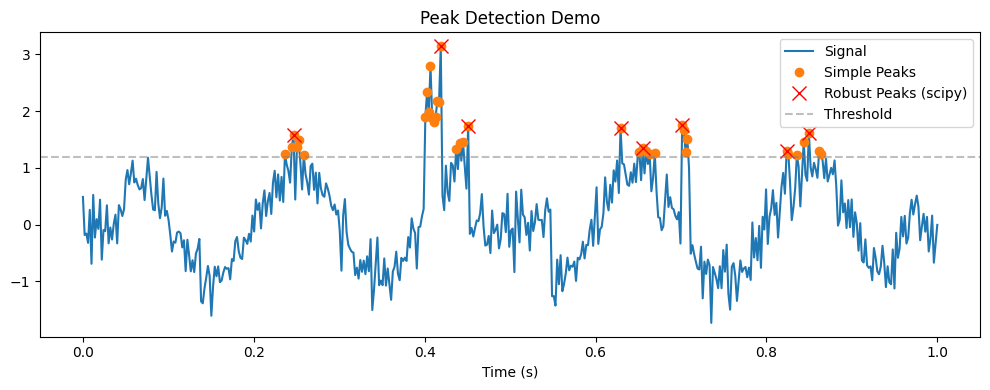

In [2]:
np.random.seed(1)
t = np.linspace(0, 1, 500)
sig = np.sin(5*2*np.pi*t) * (np.abs(np.sin(2*np.pi*t)) > 0.3) + 0.3*np.random.randn(len(t))
sig[200:210] += 2  # Add a strong peak
sig[350:355] += 1.5  # Add another

# Simple thresholding
thresh = 1.2
simple_peaks = find_peaks_simple(sig, thresh)

# Robust (scipy) method
robust_peaks, props = find_peaks_scipy(sig, height=1.2, distance=10)

plt.figure(figsize=(10,4))
plt.plot(t, sig, label='Signal')
plt.plot(t[simple_peaks], sig[simple_peaks], 'o', label='Simple Peaks')
plt.plot(t[robust_peaks], sig[robust_peaks], 'rx', markersize=10, label='Robust Peaks (scipy)')
plt.axhline(thresh, color='gray', linestyle='--', alpha=0.5, label='Threshold')
plt.title('Peak Detection Demo')
plt.xlabel('Time (s)')
plt.legend()
plt.tight_layout()
plt.show()


---
## Usage Tips

- Use robust methods (`scipy.signal.find_peaks`) for real data; tune `height`, `distance`, `prominence` to avoid noise artifacts.
- Simple thresholding is fast for clean or pre-processed signals.
- In sonar, combine with envelope detection to find echo/pulse arrival times, or count events.

**Peak detection is a core building block for event-based DSP and all range/echo analysis!**
